In [43]:
import json
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, HDBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

In [44]:
# 1. Carica tracks.json
with open('tracks_cleaned.json', encoding='utf-8') as f:
    tracks = json.load(f)
df_tracks = pd.DataFrame(tracks)

## Hierarcical

In [46]:
def get_linkage_matrix(model):
    # Create linkage matrix 
    
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [47]:
df_train = df_tracks.drop(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'language', 'album', 'swear_IT', 'swear_EN', 'swear_IT_words',
       'swear_EN_words', 'year', 'month', 'day', 'n_sentences', 'n_tokens',
       'char_per_tok', 'avg_token_per_clause', #'bpm', 'rolloff', 'flux', 'rms',
       #'flatness', 'spectral_complexity', 'pitch', 'loudness', 
       'album_name', 'album_release_date', 'album_type', 'disc_number', 'track_number',
       'duration_ms', 'explicit', 'popularity', 'id_album', 'lyrics',
       'streams@1month'], axis=1)
scaler = StandardScaler()
scaler.fit(df_train)
df_train_2 = scaler.transform(df_train)

The commented attributes are the ones that have been left in order to perform the clustering.

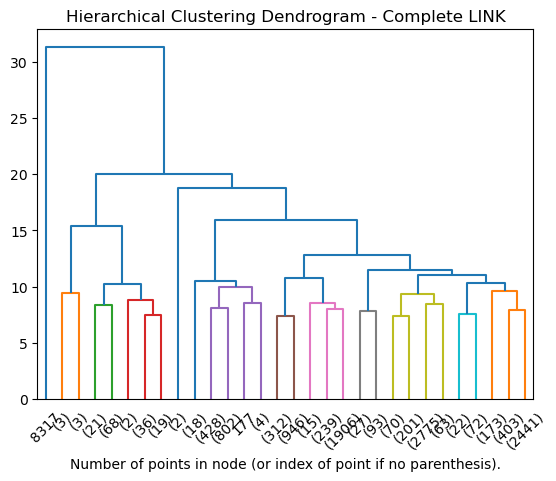

In [49]:
model_2 = AgglomerativeClustering(distance_threshold=10,
                                n_clusters=None, metric='euclidean', linkage='complete')
model_2 = model_2.fit(df_train_2)
plt.title("Hierarchical Clustering Dendrogram - Complete LINK")
plot_dendrogram(model_2, truncate_mode="lastp", color_threshold=10)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

Single and average link struggled to separate the songs, while complete link manages to do so better. But several clusters are very small, so not the best for categorizing the songs.

## HDBSCAN

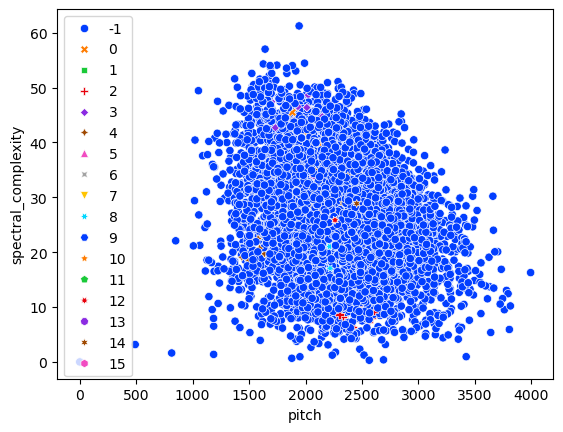

In [52]:
hdb = HDBSCAN(cluster_selection_epsilon=0.5, min_samples=5, 
              min_cluster_size=10, max_cluster_size=15,
              store_centers="centroid")
hdb.fit(df_train_2)
df_tracks['hdbscan_labels'] = hdb.labels_
sns.scatterplot(data=df_tracks, 
                x="pitch",
                y="spectral_complexity", 
                hue=hdb.labels_, 
                style=hdb.labels_, 
                palette="bright")

#plt.scatter(scaler.inverse_transform(hdb.centroids_)[:,0], scaler.inverse_transform(hdb.centroids_)[:,2], c='red', marker='*', s=200)
plt.show()

Tried several combinations of epsilon and min_samples, but the way the songs are distributed means that there is one big cluster and several very small clusters

In [54]:
df_tracks = df_tracks.drop(['hdbscan_labels'], axis=1)

## K-Means

In [56]:
%%time
sse_list = []
sil_list = []

for k in range(2, 60):
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10, max_iter=100)
    kmeans.fit(df_train_2)
    sse_list.append(kmeans.inertia_)
    sil_list.append(silhouette_score(df_train_2, kmeans.labels_))

CPU times: total: 6min 55s
Wall time: 2min 16s


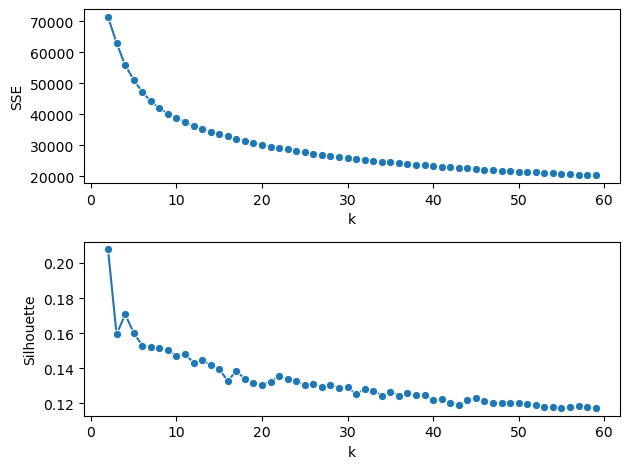

In [57]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=range(2,len(sse_list)+2), y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')

sns.lineplot(x=range(2,len(sil_list)+2), y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')

plt.tight_layout() # Adjust the padding between and around subplots

7 clusters seem to be among the best choice based on SSE and silhouette. 6 clusters would have also been good, but the clusters had fewer attributes which were higher or lower than the mean, making it less clear how to define the categories.

In [59]:
n_clust = 7
kmeans = KMeans(n_clusters=n_clust, n_init=100, max_iter=100, random_state=42)
kmeans.fit(df_train_2)

KMeans(max_iter=100, n_clusters=7, n_init=100, random_state=42)

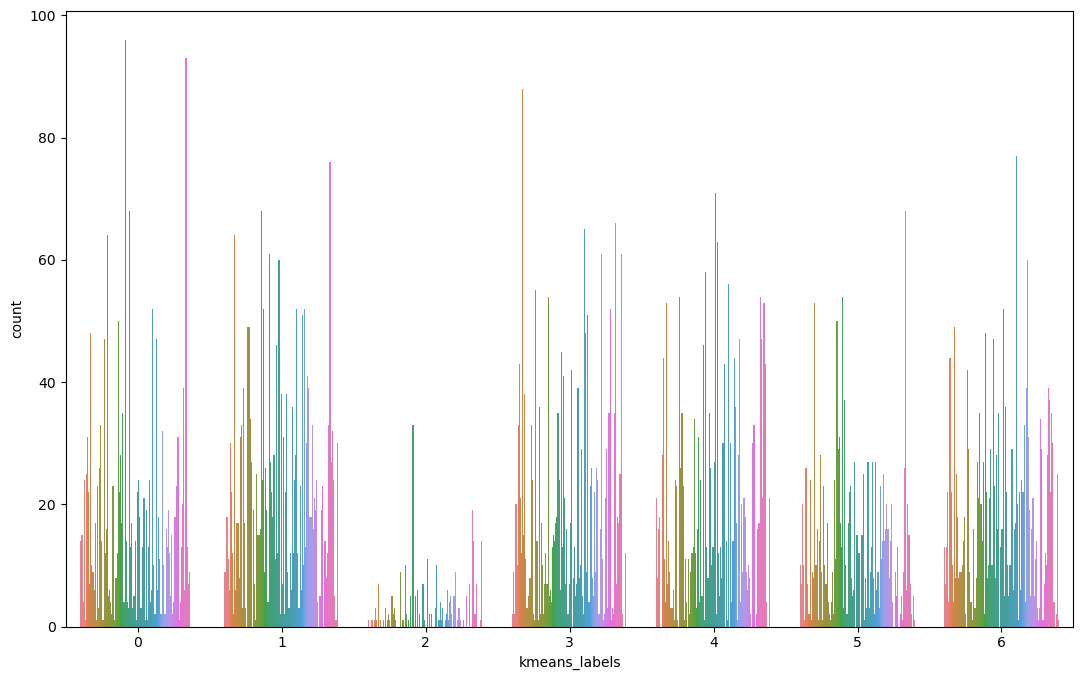

In [60]:
df_tracks['kmeans_labels'] = kmeans.labels_

fig = plt.figure(figsize=(13, 8))

sns.countplot(data=df_tracks, x='kmeans_labels', hue='primary_artist', legend=False)
plt.show()

Cluster 0: high pitch -> Melodic

Cluster 1: lowest bpm, low rolloff -> Slow Dark

Cluster 2: lowest flatness -> Clean

Cluster 3: lowest rolloff, highest loudness, highest pitch, highest rms -> Warm Bangers

Cluster 4: highest rolloff, high loudness, highest spectral_complexity -> Hype

Cluster 5: low rolloff, lowest loudness, lowest spectral_complexity, lowest rms, lowest flux -> Minimal

Cluster 6: highest bpm, high spectral_complexity -> Fast-Flow

In [62]:
label_to_cat = {0:'Melodic', 1:'Slow Dark', 2:'Clean', 3:'Warm Bangers', 4:'Hype', 5:'Minimal', 6:'Fast-Flow'}

In [63]:
for i in range(n_clust):
    df = df_tracks.loc[df_tracks['kmeans_labels']==i, 'category'] = label_to_cat[i]

In [64]:
df_tracks = df_tracks.drop(['kmeans_labels'], axis=1)
df_tracks

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month,category
0,TR934808,ART04205421,​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...",...,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",186522.0,Melodic
1,TR760029,ART04205421,POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...",...,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",194313.0,Hype
2,TR916821,ART04205421,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']",...,album,1.0,1.0,193544.0,True,39.0,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",63750.0,Warm Bangers
3,TR480968,ART04205421,CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...",...,single,1.0,2.0,169000.0,True,47.0,ALB730959,Designer sui vestiti penso di essere un outlet...,41473.0,Melodic
4,TR585039,ART04205421,LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,1,0,['cazzo'],...,album,1.0,8.0,194779.0,True,41.0,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",30553.0,Hype
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11161,TR434449,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,None,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",4663.0,Warm Bangers
11162,TR826351,ART02733420,Senza Un Posto Nel Mondo - Alternative Version,Tiziano Ferro,Marracash,it,Senza Un Posto Nel Mondo – Single,1,0,['fortuna'],...,album,1.0,20.0,248330.0,True,24.0,ALB100713,Odio questa città (città)\nSappiamo che la ver...,5686.0,Fast-Flow
11163,TR529809,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Exte...,None,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",5540.0,Melodic
11164,TR280904,ART02733420,Tempo,None,Marracash,it,Status,0,1,[],...,album,1.0,7.0,302173.0,True,37.0,ALB100713,É crudo il suono e questa vibra che ti do\nCru...,4672.0,Warm Bangers


In [65]:
# Convert DataFrame to list of dictionaries
df_tracks_json = df_tracks.to_dict(orient='records')

# Save using your exact formatting style
with open('tracks_cleaned2.json', 'w', encoding='utf-8') as f:
    json.dump(df_tracks_json, f, indent=2, ensure_ascii=False)

In [66]:
# 1. Carica tracks.json
with open('tracks_cleaned2.json', encoding='utf-8') as f:
    tracks2 = json.load(f)
df_tracks2 = pd.DataFrame(tracks2)
tracks2

[{'id': 'TR934808',
  'id_artist': 'ART04205421',
  'title': '\u200bpolka 2 :-/',
  'featured_artists': 'Ernia, Guè',
  'primary_artist': 'Rosa Chemical',
  'language': 'pl',
  'album': 'FOREVER AND EVER',
  'swear_IT': 13,
  'swear_EN': 6,
  'swear_IT_words': "['cazzo', 'cesso', 'coglioni', 'figa', 'merda', 'palle', 'piscio', 'porca', 'stronzo']",
  'swear_EN_words': "['bitch', 'fuck', 'porno', 'pussy']",
  'year': 2021.0,
  'month': 4.0,
  'day': 2.0,
  'n_sentences': 102.0,
  'n_tokens': 911.0,
  'char_per_tok': 4.1704545455,
  'avg_token_per_clause': 8.1339285714,
  'bpm': 135.32,
  'rolloff': 2895.7767,
  'flux': 1.4499,
  'rms': 0.1786,
  'flatness': 0.8202,
  'spectral_complexity': 25.7148,
  'pitch': 2311.1779,
  'loudness': 17.8675,
  'album_name': 'FOREVER AND EVER',
  'album_release_date': '2021-04-09',
  'album_type': 'album',
  'disc_number': 1.0,
  'track_number': 3.0,
  'duration_ms': 207761.0,
  'explicit': True,
  'popularity': 46.0,
  'id_album': 'ALB115557',
  'lyric